# Anomaly Detection of Network Traffic
## AI Driven Cybersecurity Course - Lab 2
---
* **Student Name:** Daniela Slavutin
* **Date:** March 2026
* **Dataset:** [KDD cup 1999 Data](https://www.kaggle.com/datasets/galaxyh/kdd-cup-1999-data)
---

### Abstract
For this lab, I selected the KDD Cup 1999 dataset, which represents network traffic.

After Analyzing the dataset, the anomalous behavior corresponds to three key MITRE ATT&CK techniques:
* Network Denial of Service (T1498) for impact
* Active Scanning (T1595) for Reconnaissance
* External Remote Services (T1133) for Initial Access.

### Data Cleaning Techniques
Drawing from personal experience as a Tier 1 SOC Analyst and industry statistics, I downsampled the anomalies to represent just 2% of the dataset, with benign traffic comprising the remaining 98%.

In real-world network environments, genuine malicious activity is a tiny fraction of the overall traffic.

Maintaining this severe class imbalance in the dataset is crucial, as training models on artificially inflated attack rates inevitably leads to an overwhelming volume of False Positives in practice.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA


# Data Preparation

sns.set_theme(style="whitegrid")

col_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count',
    'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'label', 'difficulty'
]

df = pd.read_csv("kddcup.data_10_percent.gz", header=None, names=col_names)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst rows:")
print(df.head())
print(f"\nLabel distribution:")
print(df['label'].value_counts())

# Data Cleaning
df['label'] = df['label'].str.replace('.', '', regex=False)

if 'difficulty'in df.columns:
    df = df.drop(columns=['difficulty'])

normal_df = df[df['label'] == 'normal']
attack_df = df[df['label'] != 'normal']

n_attacks_needed = int((0.02 / 0.98) * len(normal_df))

attack_sample = attack_df.sample(n=n_attacks_needed, random_state=42)

df_sampled = pd.concat([normal_df, attack_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

df_sampled['is_anomaly'] = (df_sampled['label'] != 'normal').astype(int)

np.random.seed(42)
df_sampled['hour'] = np.random.normal(loc=14, scale=4, size=len(df_sampled)).astype(int) % 24

print("=== After Downsampling ===")
print(f"Final dataset shape: {df_sampled.shape}")
print(df_sampled['is_anomaly'].value_counts(normalize=True).map('{:.2}'.format))

print("Loading the dataset...")
print(f" Shape: {df_sampled.shape[0]:,} rows × {df_sampled.shape[1]} columns")

df_sampled.head(20)

Dataset shape: (494021, 43)

First rows:
   duration protocol_type service flag  src_bytes  dst_bytes  land  \
0         0           tcp    http   SF        181       5450     0   
1         0           tcp    http   SF        239        486     0   
2         0           tcp    http   SF        235       1337     0   
3         0           tcp    http   SF        219       1337     0   
4         0           tcp    http   SF        217       2032     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                     1.0   
1               0       0    0  ...                     1.0   
2               0       0    0  ...                     1.0   
3               0       0    0  ...                     1.0   
4               0       0    0  ...                     1.0   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                     0.0                         0.11   
1                     0.0                  

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,is_anomaly,hour
0,0,udp,private,SF,105,145,0,0,0,0,...,0.01,0.00,0.00,0.00,0.0,0.0,0.00,normal,0,15
1,0,tcp,ftp_data,SF,1214,0,0,0,0,0,...,0.09,0.71,0.00,0.00,0.0,0.0,0.00,normal,0,13
2,0,tcp,http,SF,237,275,0,0,0,0,...,0.00,0.00,0.00,0.00,0.0,0.0,0.00,normal,0,16
3,0,tcp,http,SF,222,313,0,0,0,0,...,0.00,0.00,0.00,0.00,0.0,0.0,0.00,normal,0,20
4,0,tcp,smtp,SF,1513,284,0,0,0,0,...,0.04,0.01,0.02,0.00,0.0,0.0,0.00,normal,0,13
5,4,tcp,smtp,SF,1178,337,0,0,0,0,...,0.04,0.01,0.01,0.00,0.0,0.0,0.00,normal,0,13
6,14,tcp,smtp,SF,1017,335,0,0,0,0,...,0.04,0.01,0.01,0.00,0.0,0.0,0.00,normal,0,20
7,0,udp,ntp_u,SF,48,48,0,0,0,0,...,0.01,0.05,0.00,0.00,0.0,0.0,0.00,normal,0,17
8,0,tcp,http,SF,241,9443,0,0,0,0,...,0.00,0.06,0.05,0.00,0.0,0.0,0.00,normal,0,12
9,1,tcp,smtp,SF,1664,334,0,0,0,0,...,0.09,0.02,0.01,0.00,0.0,0.0,0.00,normal,0,16


In [2]:
# The available columns and their datatypes

print("Datatset structure overview:\n")
df_sampled.info()

print("\nList of Columns:")
print(", ".join(df_sampled.columns))

Datatset structure overview:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99263 entries, 0 to 99262
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     99263 non-null  int64  
 1   protocol_type                99263 non-null  object 
 2   service                      99263 non-null  object 
 3   flag                         99263 non-null  object 
 4   src_bytes                    99263 non-null  int64  
 5   dst_bytes                    99263 non-null  int64  
 6   land                         99263 non-null  int64  
 7   wrong_fragment               99263 non-null  int64  
 8   urgent                       99263 non-null  int64  
 9   hot                          99263 non-null  int64  
 10  num_failed_logins            99263 non-null  int64  
 11  logged_in                    99263 non-null  int64  
 12  num_compromised              99263 non-null 

### Analytical Summary
The label distribution reveals a highly realistic network environment. Normal traffic heavily dominates the dataset with 97,278 instances.

The anomalous activity is primarily driven by noisy DoS attacks, specifically 'smurf' (ICMP flood) and 'neptune' (SYN flood), which together account over 97% of all malicious records.

Conversely, stealthier activities such as network reconnaissance ('ipsweep', 'portsweep', 'satan') and remote access attempts('warezclient') appear in minute quantities. This distribution perfectly mirrors real-world triage, where volumetric attacks generate massive log activity, while targeted probing remains sparse and difficult to detect.

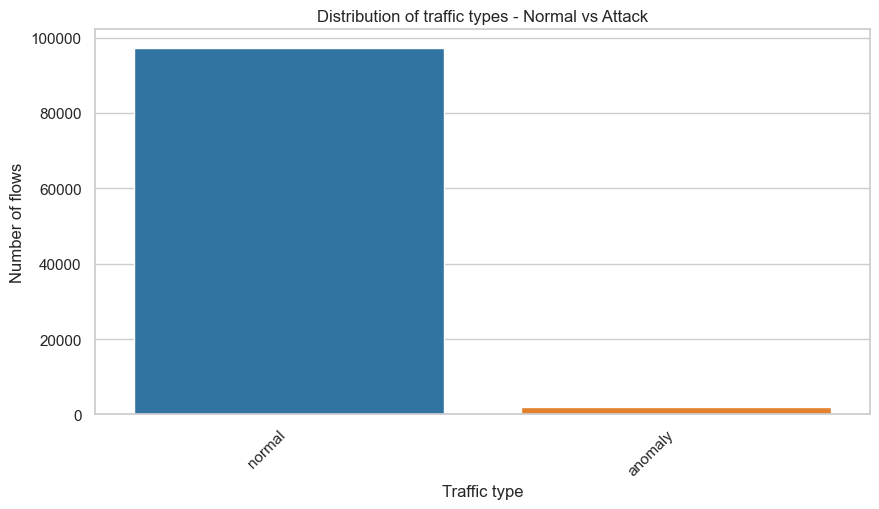

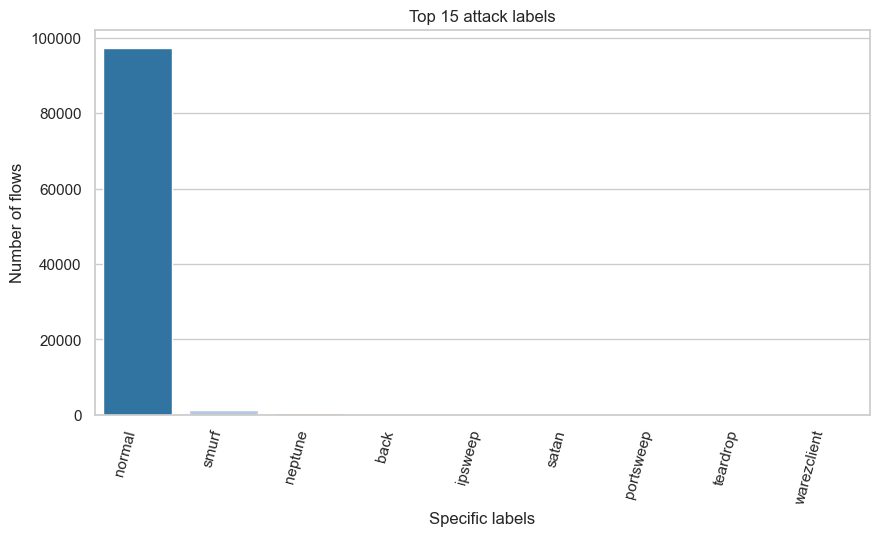

In [3]:
# Distribution of attack classes and labels
df_sampled['traffic_type'] = df_sampled['is_anomaly'].map({0: 'normal', 1: 'anomaly'})

sns.set(style="whitegrid", palette="tab10")

# Distribution of attack classes
plt.figure(figsize=(10, 5))
sns.countplot(data=df_sampled, x="traffic_type", hue="traffic_type", order=df_sampled["traffic_type"].value_counts().index, palette="tab10")
plt.title("Distribution of traffic types - Normal vs Attack")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of flows")
plt.xlabel("Traffic type")
plt.show()

# Distribution of Label
top_lables = df_sampled["label"].value_counts().head(15).reset_index()
top_lables.columns = ["label", "count"]

plt.figure(figsize=(10, 5))
sns.barplot(data=top_lables, x="label", y="count", hue="label", legend=False, palette="tab20")
plt.title("Top 15 attack labels")
plt.xticks(rotation=75, ha="right")
plt.ylabel("Number of flows")
plt.xlabel("Specific labels")
plt.show()

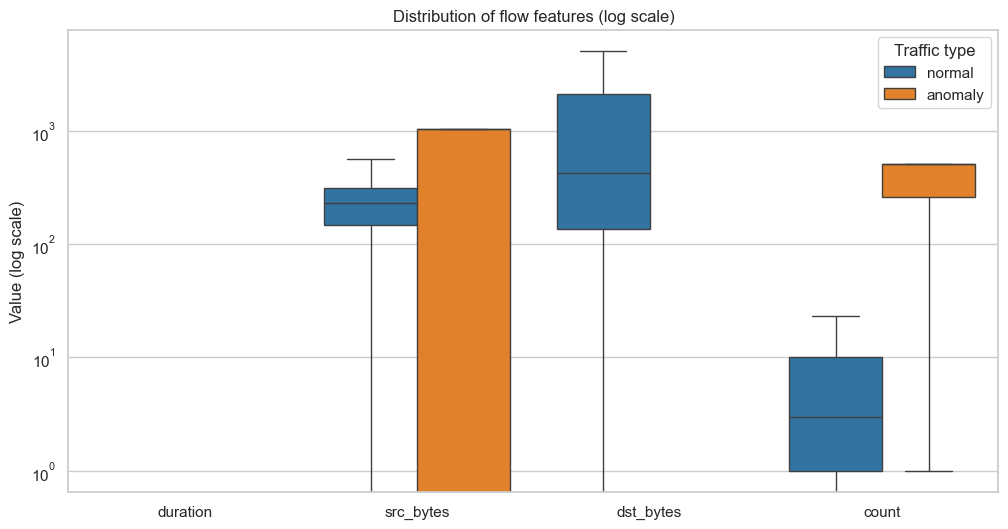

In [4]:
# Comparing numeric features between normal and attack flows

features = ["duration", "src_bytes", "dst_bytes", "count"]

subset = df_sampled.melt(id_vars="traffic_type", value_vars=features, var_name="Feature", value_name="value")
plt.figure(figsize=(12, 6))
sns.boxplot(data=subset, x="Feature", y="value", hue="traffic_type", showfliers=False)
plt.yscale('log')
plt.title("Distribution of flow features (log scale)")
plt.xlabel("")
plt.ylabel("Value (log scale)")
plt.legend(title="Traffic type")
plt.show()

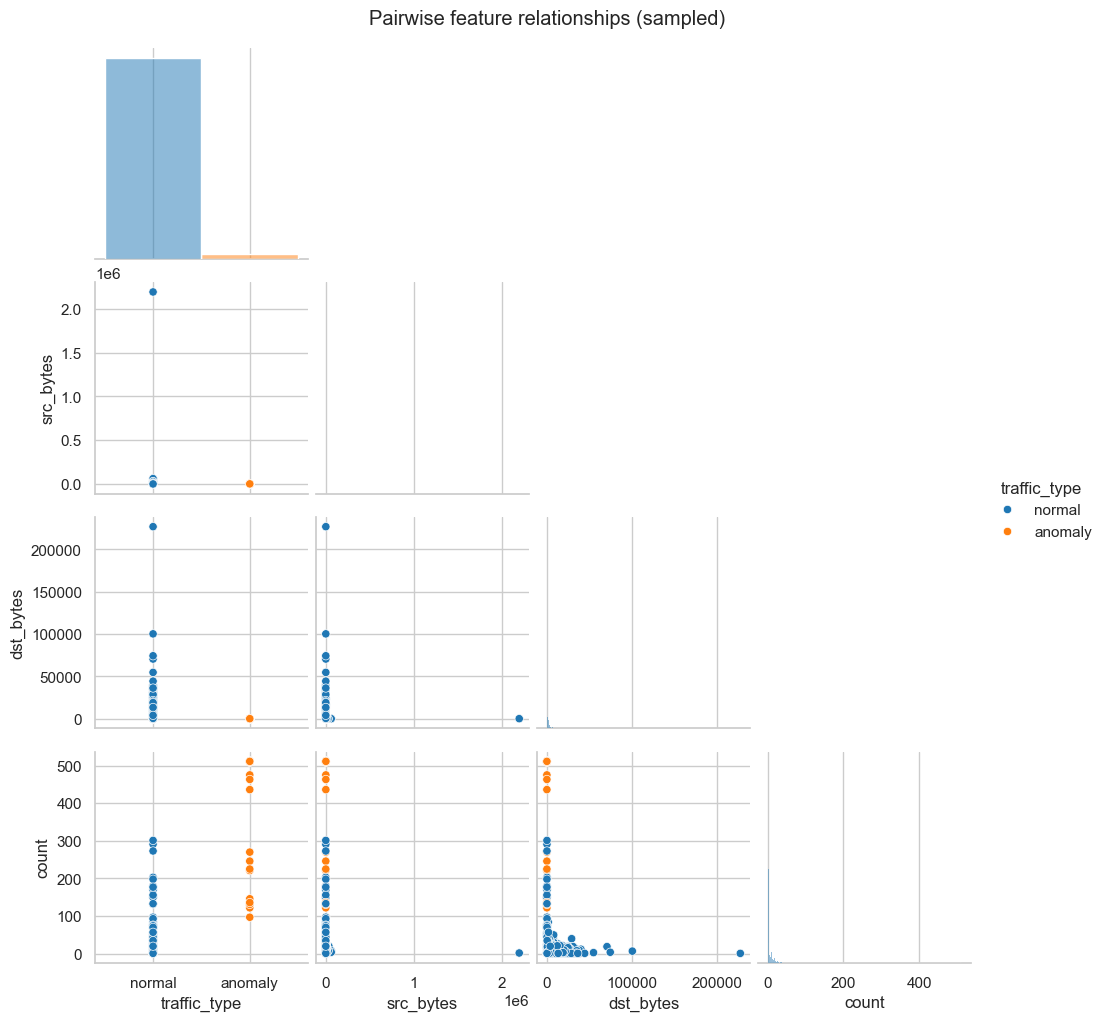

In [5]:
sample = df_sampled.sample(2000, random_state=42)

sns.pairplot(
    data=sample,
    vars=["traffic_type", "src_bytes", "dst_bytes", "count"],
    hue="traffic_type",
    corner=True,
    diag_kind="hist",
    palette="tab10",
)
plt.suptitle("Pairwise feature relationships (sampled)", y=1.02)
plt.show()

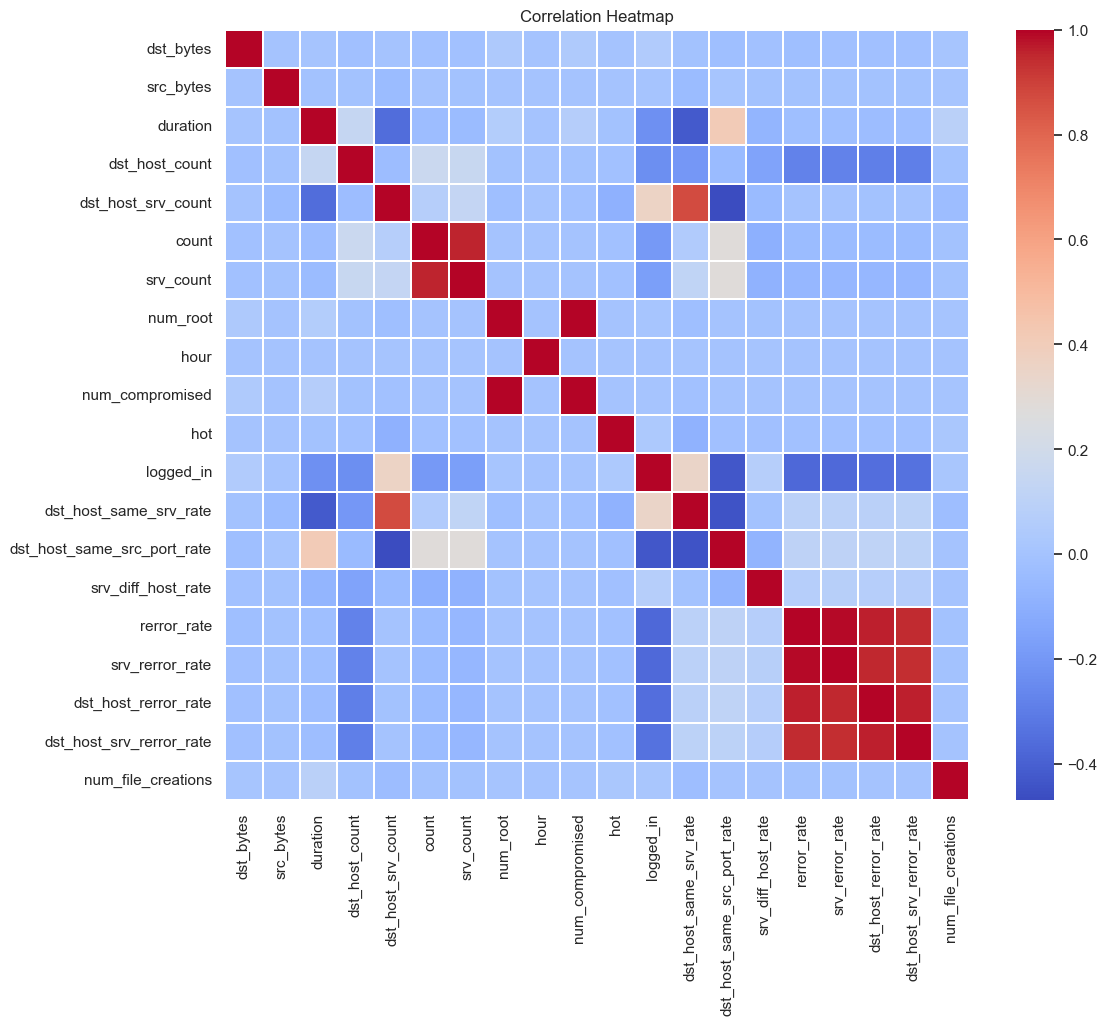

In [6]:
# Feature correlation heatmap
corr = df_sampled.select_dtypes(include=["int64", "float64"]).corr()

top_var_cols = df_sampled.select_dtypes(include=["int64", "float64"]).var().nlargest(20).index
plt.figure(figsize=(12, 10))
sns.heatmap(corr.loc[top_var_cols, top_var_cols], cmap="coolwarm", annot=False, linewidths=0.3)
plt.title("Correlation Heatmap")
plt.show()

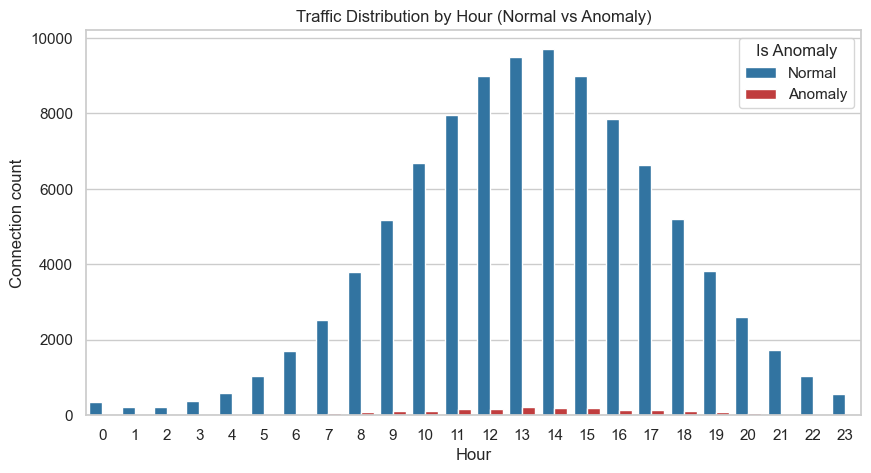

In [7]:
# Normal vs Anomaly traffic distributed by hour
plt.figure(figsize=(10, 5))
sns.countplot(data=df_sampled, x='hour', hue='is_anomaly', palette=['#1f77b4', '#d62728'])
plt.title("Traffic Distribution by Hour (Normal vs Anomaly)")
plt.xlabel("Hour")
plt.ylabel("Connection count")
plt.legend(title="Is Anomaly", labels=['Normal', 'Anomaly'])
plt.show()

In [8]:
# Quick Summary
print("Top 10 Classes:")
print(df_sampled['traffic_type'].value_counts().head(10).to_string(), "\n")

print("Top 10 lables:")
print(df_sampled['label'].value_counts().head(10).to_string(), "\n")

print("Basic numeric statistics:")
print(df_sampled[["traffic_type", "src_bytes", "dst_bytes", "count"]].describe().T)

Top 10 Classes:
traffic_type
normal     97278
anomaly     1985 

Top 10 lables:
label
normal         97278
smurf           1371
neptune          571
back              15
ipsweep            9
satan              6
portsweep          5
teardrop           5
warezclient        3 

Basic numeric statistics:
             count         mean           std  min    25%    50%     75%  \
src_bytes  99263.0  1155.169066  33888.666986  0.0  146.0  231.0   315.0   
dst_bytes  99263.0  3318.223356  37203.610019  0.0  111.0  398.0  2063.0   
count      99263.0    16.116912     62.593154  0.0    1.0    3.0    10.0   

                 max  
src_bytes  2194619.0  
dst_bytes  5134218.0  
count          511.0  



 Evaluation Metrics:
              precision    recall  f1-score   support

  Normal (0)       0.99      0.99      0.99     97278
 Anomaly (1)       0.31      0.31      0.31      1985

    accuracy                           0.97     99263
   macro avg       0.65      0.65      0.65     99263
weighted avg       0.97      0.97      0.97     99263



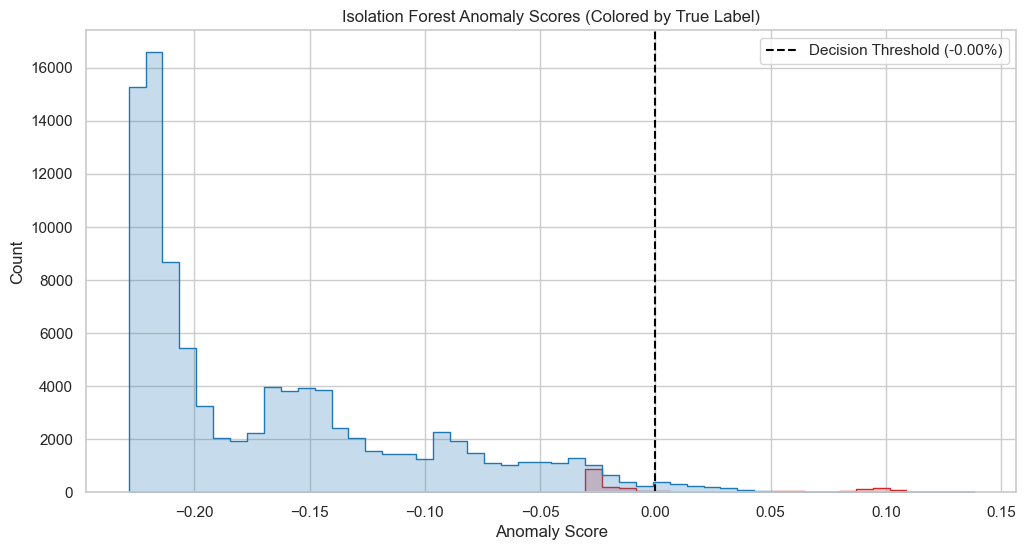

In [9]:
# Data preprocessing for isolation forest
cols_to_drop = ['label', 'is_anomaly']
if 'traffic_type' in df_sampled.columns:
    cols_to_drop.append('traffic_type')

X = df_sampled.drop(columns=cols_to_drop)
y_true = df_sampled['is_anomaly']

cat_cols = ['protocol_type', 'service', 'flag']
num_cols = X.columns.drop(cat_cols)
num_cols = X.columns.drop(cat_cols)

X_encoded = pd.get_dummies(X, columns=cat_cols)

scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

iso_forest = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
iso_forest.fit(X_encoded)

# Training part
preds = iso_forest.predict(X_encoded)
y_pred = (preds == -1).astype(int)

scores = -iso_forest.decision_function(X_encoded)
df_sampled['anomaly_score'] = scores
df_sampled['predicted_anomaly'] = y_pred

# Evaluation part
print("\n Evaluation Metrics:")
print(classification_report(y_true, y_pred, target_names=['Normal (0)', 'Anomaly (1)']))

plt.figure(figsize=(12, 6))
sns.histplot(data=df_sampled, x="anomaly_score", hue="is_anomaly", bins=50, palette=['#1f77b4', '#d62728'], element='step', common_norm=False)
plt.title('Isolation Forest Anomaly Scores (Colored by True Label)')
plt.xlabel('Anomaly Score')
plt.ylabel('Count')

threshold = np.percentile(scores, 98)
plt.axvline(x=threshold, color='black', linestyle='--', label=f'Decision Threshold ({threshold:.2%})')
plt.legend()
plt.show()

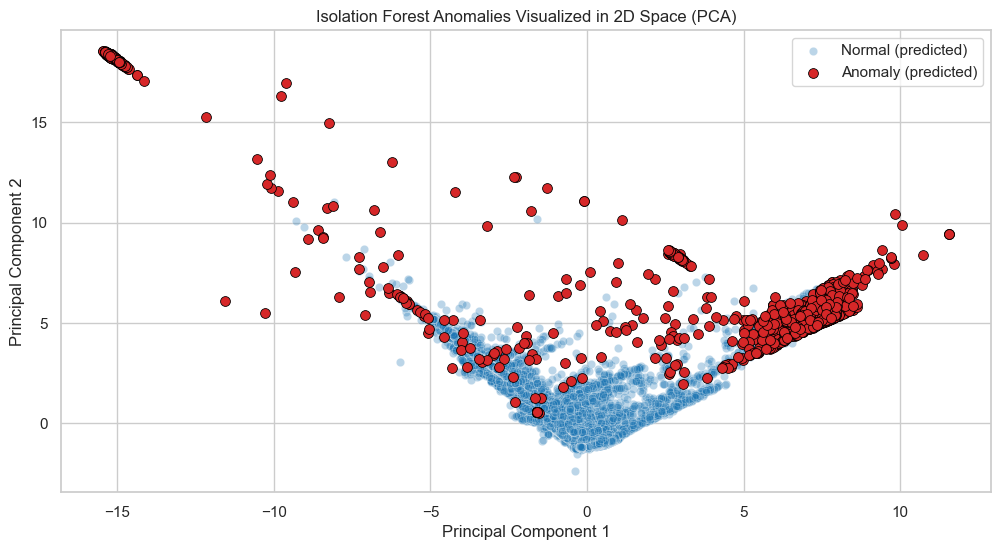

In [10]:
# 2D visualization with PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_encoded)

df_sampled['PCA_1'] = X_pca[:, 0]
df_sampled['PCA_2'] = X_pca[:, 1]

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_sampled[df_sampled['predicted_anomaly'] == 0],
    x="PCA_1",
    y="PCA_2",
    color='#1f77b4', alpha=0.3, label='Normal (predicted)'
)

sns.scatterplot(
    data=df_sampled[df_sampled['predicted_anomaly'] == 1],
    x="PCA_1",
    y="PCA_2",
    color='#d62728', edgecolor='black', s=50, label='Anomaly (predicted)'
)

plt.title("Isolation Forest Anomalies Visualized in 2D Space (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [11]:
from sklearn.datasets import make_blobs
n_normal = 500
X_normal, _ = make_blobs(n_samples=n_normal, centers=[[0, 0]], cluster_std=0.8, random_state=42)

In [12]:
n_outliers = 25
rng = np.random.RandomState(42)

r = rng.uniform(5, 7, size=n_outliers)
theta = rng.uniform(0, 2 * np.pi, size=n_outliers)
X_outliers = np.c_[r * np.cos(theta), r * np.sin(theta)]

X = np.vstack([X_normal, X_outliers])

In [13]:
model = IsolationForest(n_estimators=200, contamination=float(n_outliers) / (n_normal + n_outliers),random_state=42)
model.fit(X)

IsolationForest(contamination=0.047619047619047616, n_estimators=200,
                random_state=42)

In [14]:
# Anomaly prediction
scores = -model.decision_function(X)
labels = model.predict(X)

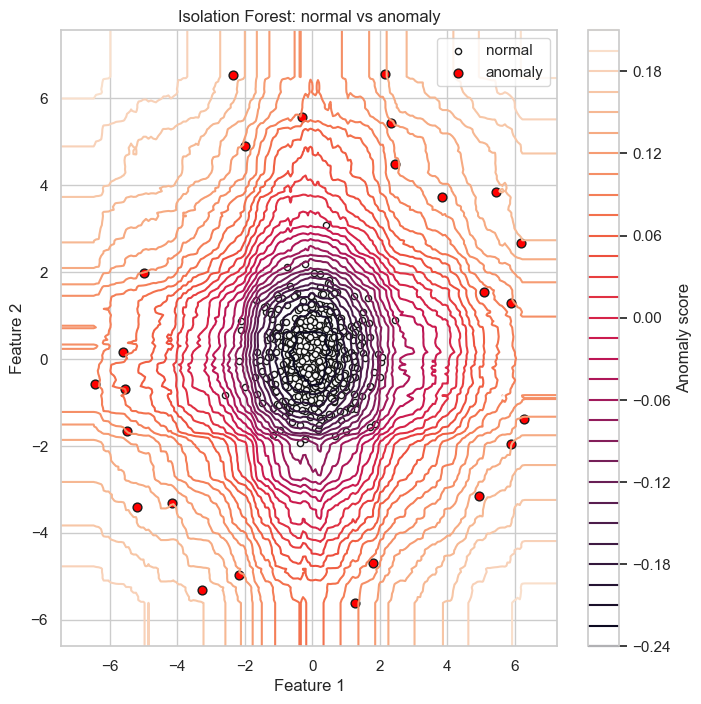

In [15]:
# Anomaly map
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
grid_scores = -model.decision_function(grid)
grid_scores = grid_scores.reshape(xx.shape)

plt.figure(figsize=(8, 8))

# Dark background for anomalies
contour = plt.contour(xx, yy, grid_scores, levels=30)
plt.colorbar(contour, label="Anomaly score")

# normal points
plt.scatter(
    X[labels == 1, 0],
    X[labels == 1, 1],
    s=20,
    edgecolor="k",
    facecolor="white",
    label="normal"
)

# anomalies
plt.scatter(
    X[labels == -1, 0],
    X[labels == -1, 1],
    s=40,
    edgecolor="k",
    facecolor="red",
    label="anomaly"
)

plt.legend()
plt.title("Isolation Forest: normal vs anomaly")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis()
plt.show()

### Conclusions
As visualized in the 2D PCA projection, the Isolation Forest algorithm successfully identified the underlying structure of the network traffic.

Normal behavior forms a dense, continuous cluster in the central region, representing the routine 'white noise' of the network.

In contrast, the model effectively isolated the anomalies, pushing them to the sparse outer edges of the graph as isolated points, confirming that the attacks are statistically distinct from benign traffic.